In [2]:
import pandas as pd 
import numpy as np
import seaborn as sns
import missingno as msno
import matplotlib.pyplot as plt
import plotly.express as px

In [ ]:
df = pd.read_csv('apartments_rent_pl_2024_01.csv')
df.head(5)



,id,city,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,...,pharmacyDistance,ownership,buildingMaterial,condition,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price
0,2a1a6db97ff122d6bc148abb6f0e498a,szczecin,blockOfFlats,52.00,2.0,3.0,3.0,2008.0,53.460535,14.545416,...,0.307,condominium,brick,NaN,yes,yes,no,no,no,3500
1,368e16142922433c709e6921a3b8f2a8,szczecin,blockOfFlats,70.00,3.0,7.0,11.0,1985.0,53.378485,14.657089,...,0.086,condominium,concreteSlab,premium,no,yes,yes,no,no,2900
2,655acd54eb518a718fd1f59fd7161c61,szczecin,blockOfFlats,43.00,2.0,3.0,3.0,1960.0,53.425946,14.559489,...,0.338,condominium,concreteSlab,premium,no,yes,no,no,yes,2900
3,99f85bbc55d110aa5a79ad4c7d5a0562,szczecin,blockOfFlats,46.70,2.0,1.0,4.0,1980.0,53.446990,14.556851,...,0.096,condominium,concreteSlab,premium,no,no,no,no,yes,2400
4,601b83a79fb6b89fe8e488bfcdd5e872,szczecin,NaN,56.20,3.0,1.0,4.0,NaN,53.441100,14.549100,...,0.050,condominium,NaN,NaN,no,no,NaN,no,no,3000
5,a6947320455a7f8afd2d53497a5b47e9,szczecin,blockOfFlats,70.00,3.0,1.0,2.0,2000.0,53.442188,14.486052,...,0.273,condominium,brick,NaN,yes,no,no,no,no,3200
6,ca7c8be77d6ee03aab89cdecf4ee4b43,szczecin,blockOfFlats,28.16,1.0,2.0,3.0,2022.0,53.417000,14.535800,...,0.503,condominium,NaN,NaN,yes,yes,yes,no,no,1980
7,aae4994ab375e107dcc375f3360bd3d9,szczecin,tenement,32.00,1.0,2.0,4.0,1930.0,53.434836,14.548864,...,0.271,condominium,brick,premium,no,no,NaN,no,no,1500
8,b83458393eb79b3ecdb13de56a6e2676,szczecin,blockOfFlats,76.38,3.0,1.0,1.0,1954.0,53.435478,14.512039,...,0.278,condominium,brick,premium,yes,no,no,no,no,3300
9,755bcd527418bdc97e6fb6b4e68a81bb,szczecin,apartmentBuilding,60.00,3.0,4.0,4.0,2021.0,53.393732,14.492816,...,0.522,condominium,brick,premium,no,no,yes,no,no,3250


In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8430 entries, 0 to 8429
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    8430 non-null   object 
 1   city                  8430 non-null   object 
 2   type                  6227 non-null   object 
 3   squareMeters          8430 non-null   float64
 4   rooms                 8430 non-null   float64
 5   floor                 7400 non-null   float64
 6   floorCount            8259 non-null   float64
 7   buildYear             5938 non-null   float64
 8   latitude              8430 non-null   float64
 9   longitude             8430 non-null   float64
 10  centreDistance        8430 non-null   float64
 11  poiCount              8430 non-null   float64
 12  schoolDistance        8428 non-null   float64
 13  clinicDistance        8425 non-null   float64
 14  postOfficeDistance    8425 non-null   float64
 15  kindergartenDistance 

np.int64(0)

In [10]:
#Usuwamy duplikaty z danych, których wsm nie było, ale używamy funkcji w razie czego
df.drop_duplicates()

,id,city,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,...,pharmacyDistance,ownership,buildingMaterial,condition,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price
0,2a1a6db97ff122d6bc148abb6f0e498a,szczecin,blockOfFlats,52.0,2.0,3.0,3.0,2008.0,53.460535,14.545416,...,0.307,condominium,brick,NaN,yes,yes,no,no,no,3500
1,368e16142922433c709e6921a3b8f2a8,szczecin,blockOfFlats,70.0,3.0,7.0,11.0,1985.0,53.378485,14.657089,...,0.086,condominium,concreteSlab,premium,no,yes,yes,no,no,2900
2,655acd54eb518a718fd1f59fd7161c61,szczecin,blockOfFlats,43.0,2.0,3.0,3.0,1960.0,53.425946,14.559489,...,0.338,condominium,concreteSlab,premium,no,yes,no,no,yes,2900
3,99f85bbc55d110aa5a79ad4c7d5a0562,szczecin,blockOfFlats,46.7,2.0,1.0,4.0,1980.0,53.446990,14.556851,...,0.096,condominium,concreteSlab,premium,no,no,no,no,yes,2400
4,601b83a79fb6b89fe8e488bfcdd5e872,szczecin,NaN,56.2,3.0,1.0,4.0,NaN,53.441100,14.549100,...,0.050,condominium,NaN,NaN,no,no,NaN,no,no,3000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8425,aeb9ea42eecfe32b2f791efe372a2e76,bydgoszcz,tenement,45.0,2.0,1.0,1.0,NaN,53.129551,18.029431,...,0.024,condominium,brick,NaN,no,no,NaN,no,no,2500
8426,4018cc5a9fd48bb2d66b84bc5e1b46ab,bydgoszcz,tenement,55.0,3.0,2.0,2.0,NaN,53.129551,18.029431,...,0.024,condominium,brick,NaN,no,no,no,no,no,3200
8427,89fdf9ecda6fe6aa95e34528fa82f55f,bydgoszcz,blockOfFlats,48.0,2.0,3.0,3.0,2019.0,53.121200,17.992500,...,0.300,condominium,brick,NaN,no,no,no,no,no,2700
8428,095b187d0bbce092d4b03164e89710c5,bydgoszcz,blockOfFlats,50.0,2.0,1.0,3.0,2019.0,53.121200,17.992500,...,0.300,condominium,brick,NaN,no,yes,no,no,no,2800


In [11]:
#Sprawdzamy brak idanych
df.isna().sum()



id                         0
city                       0
type                    2203
squareMeters               0
rooms                      0
floor                   1030
floorCount               171
buildYear               2492
latitude                   0
longitude                  0
centreDistance             0
poiCount                   0
schoolDistance             2
clinicDistance             5
postOfficeDistance         5
kindergartenDistance       7
restaurantDistance        24
collegeDistance          104
pharmacyDistance          13
ownership                  0
buildingMaterial        3459
condition               6223
hasParkingSpace            0
hasBalcony                 0
hasElevator              454
hasSecurity                0
hasStorageRoom             0
price                      0
dtype: int64

In [29]:
#identyfikacja braków danych 
df['squareMeters'].unique()
#nazwy są git, ale niektóre kolumny mają brak danych, więc je uzupełniamy



array([52.  , 70.  , 43.  , ..., 54.35, 48.18, 25.58], shape=(1380,))

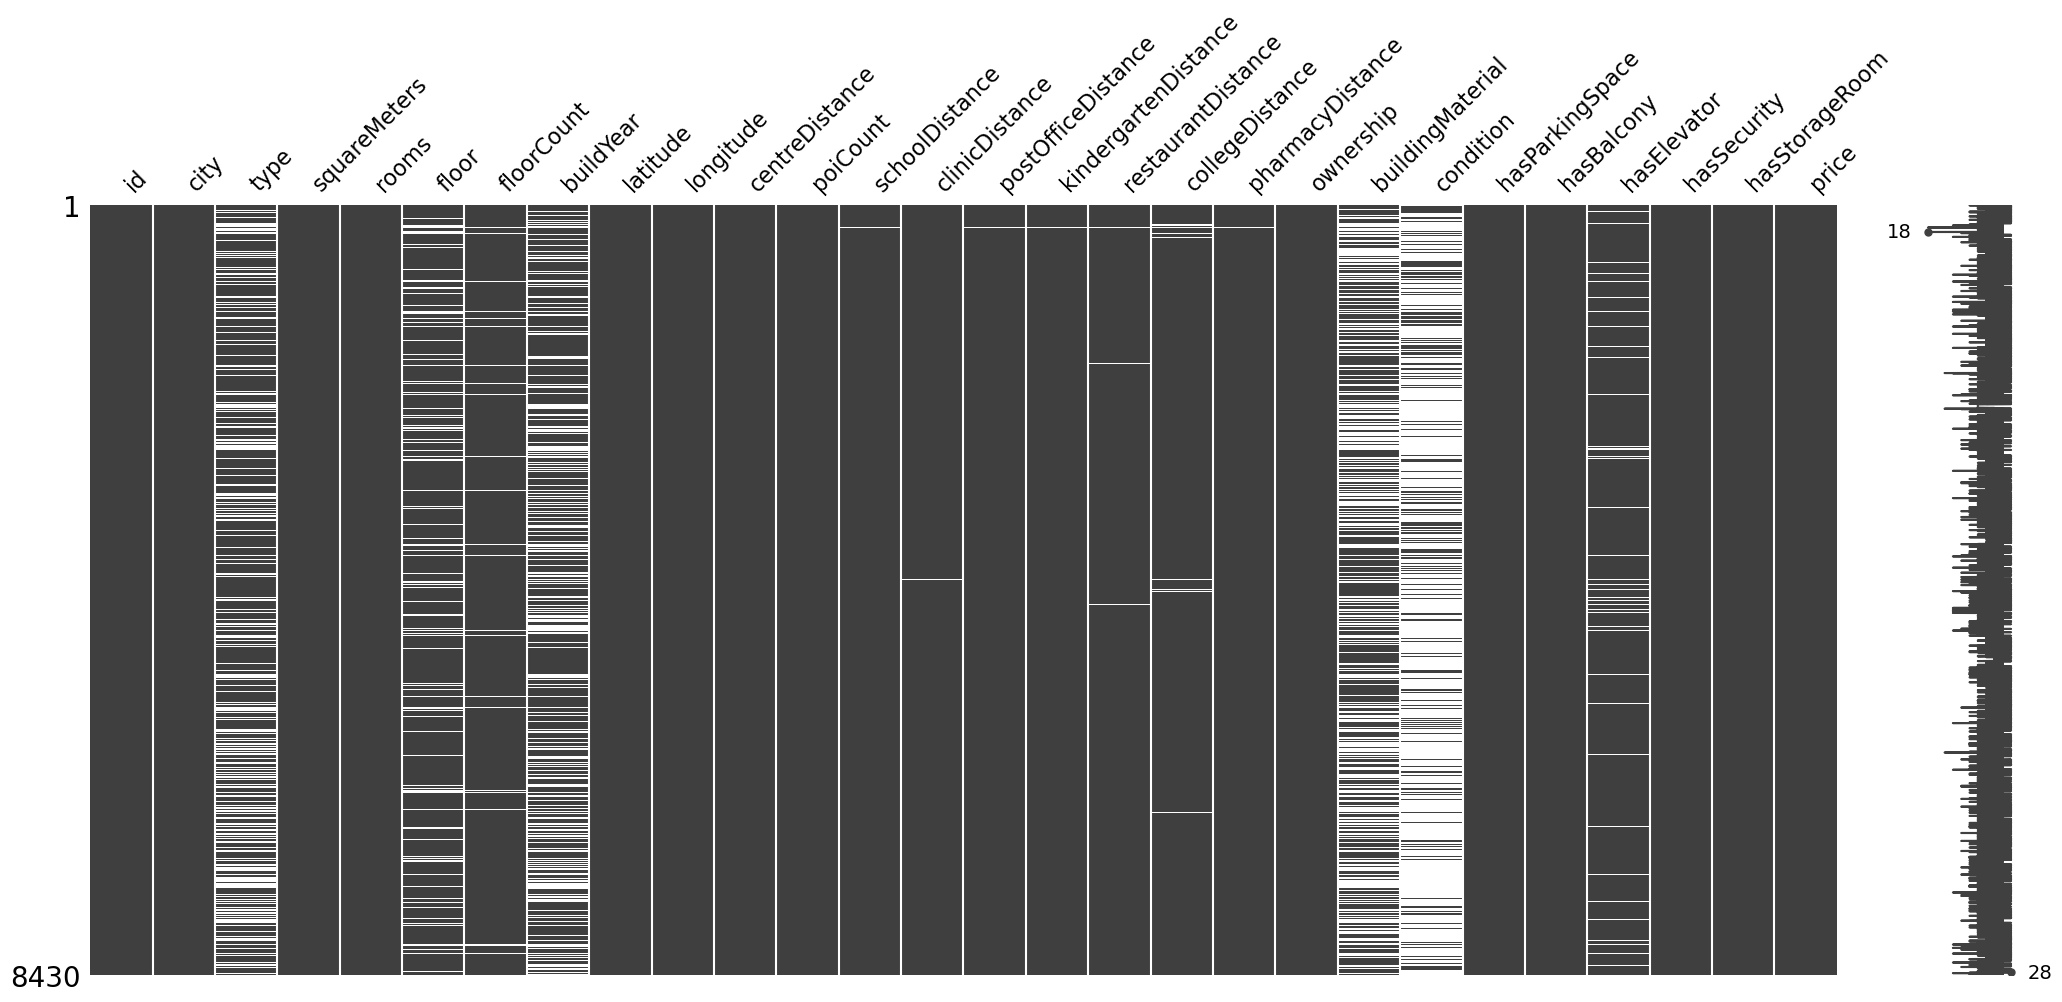

In [52]:
#wizualizacja braków danych
msno.matrix(df)
plt.show()

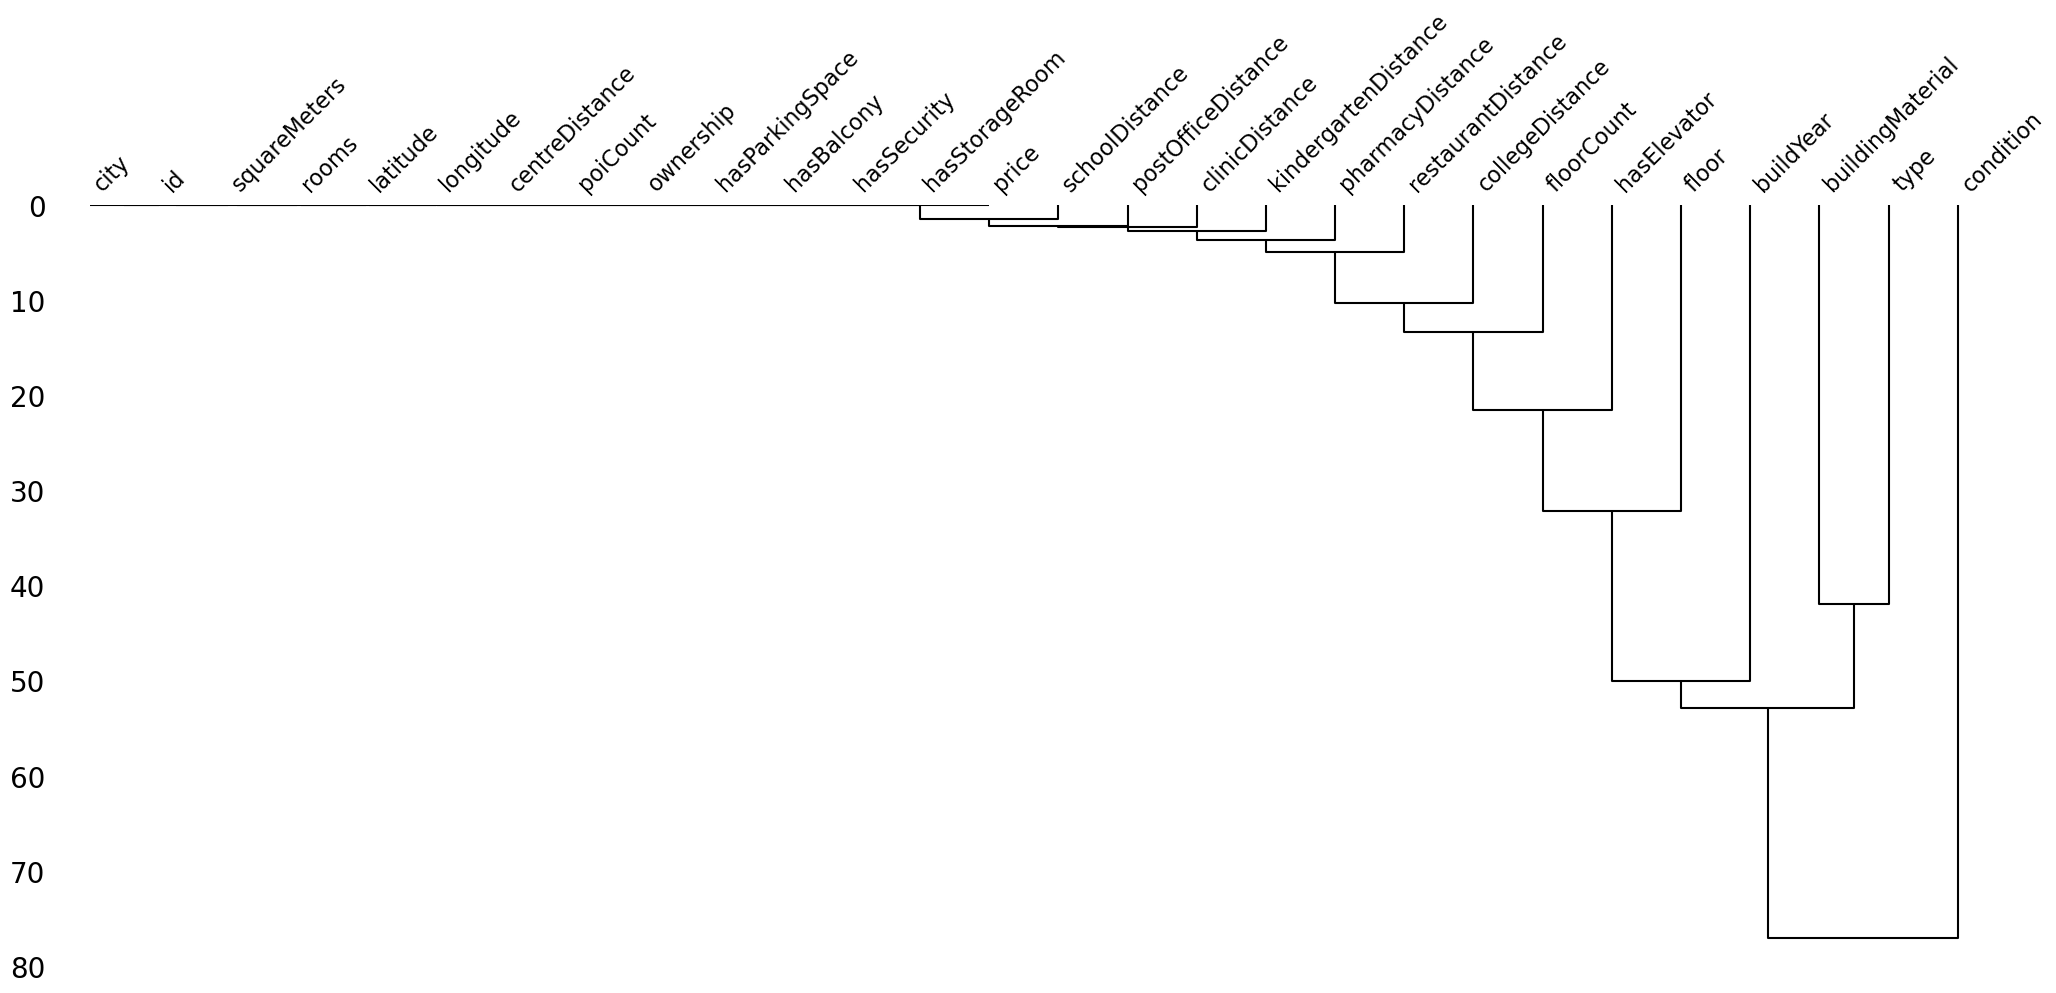

In [53]:
#wizualizacja połączenia braków danych
msno.dendrogram(df)
plt.show()

<Axes: >

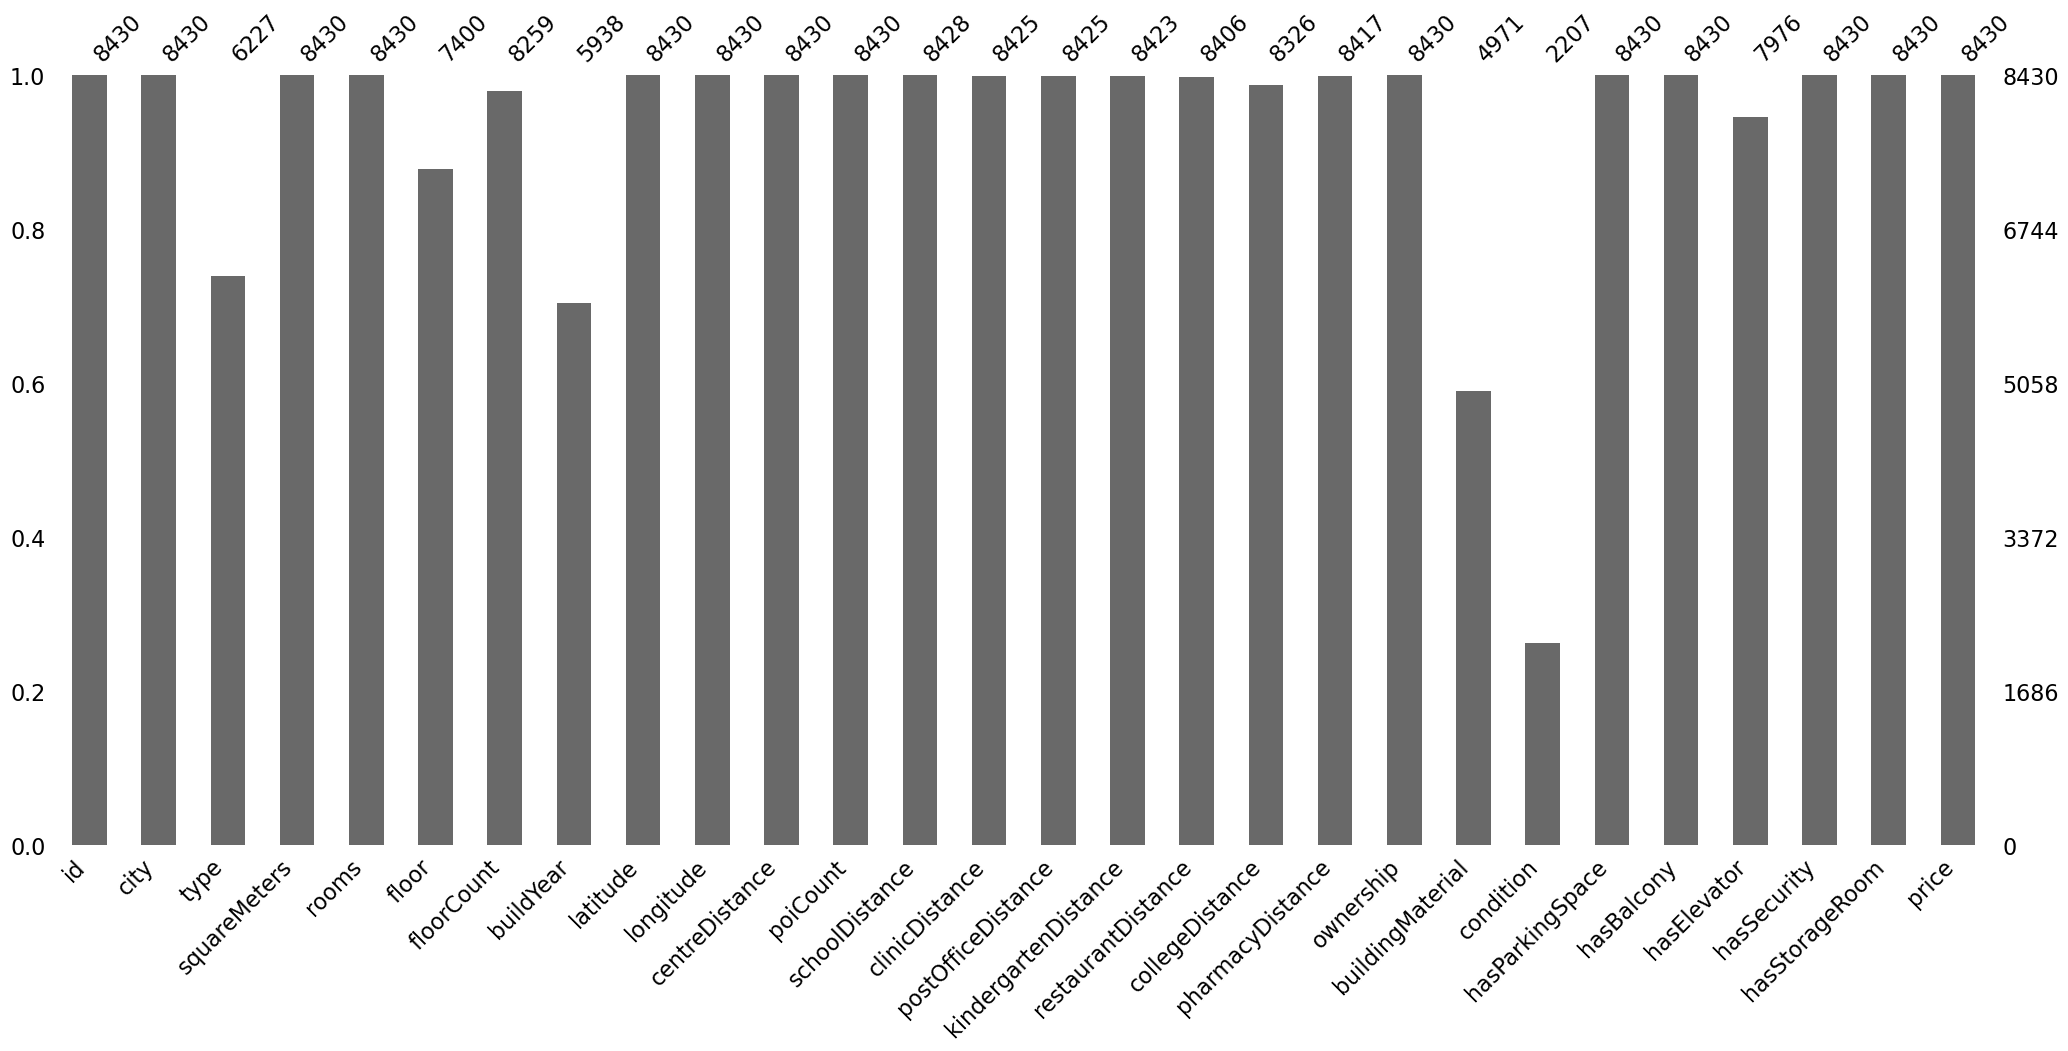

In [ ]:
#braki procentowe 
msno.bar(df)

In [ ]:
df['type'] = df['type'].fillna('unknown')
df['buildYear'] = df['buildYear'].fillna(0)
df['floor'] = df['floor'].fillna(-1)
df['buildingMaterial'] = df['buildingMaterial'].fillna('unknown')
df['hasElevator'] = df['hasElevator'].fillna('unknown')

#ze względu na dużą liczbę braków, usuwamy kolumnę conditio z analizy 
df = df.drop(columns=['condition'])
print(df.info())


KeyError: "['condition'] not found in axis"

In [21]:
df_braki = ['collegeDistance', 'pharmacyDistance', 'restaurantDistance', 'schoolDistance', 'postOfficeDistance','kindergartenDistance', 'clinicDistance','floorCount']
df_cleaned = df.dropna(subset=df_braki)
df_cleaned.info()


<class 'pandas.core.frame.DataFrame'>
Index: 8122 entries, 0 to 8429
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    8122 non-null   object 
 1   city                  8122 non-null   object 
 2   type                  8122 non-null   object 
 3   squareMeters          8122 non-null   float64
 4   rooms                 8122 non-null   float64
 5   floor                 8122 non-null   float64
 6   floorCount            8122 non-null   float64
 7   buildYear             8122 non-null   float64
 8   latitude              8122 non-null   float64
 9   longitude             8122 non-null   float64
 10  centreDistance        8122 non-null   float64
 11  poiCount              8122 non-null   float64
 12  schoolDistance        8122 non-null   float64
 13  clinicDistance        8122 non-null   float64
 14  postOfficeDistance    8122 non-null   float64
 15  kindergartenDistance  8122

In [ ]:
)

,id,city,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,...,collegeDistance,pharmacyDistance,ownership,buildingMaterial,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price
0,2a1a6db97ff122d6bc148abb6f0e498a,szczecin,blockOfFlats,52.00,2.0,3.0,3.0,2008.0,53.460535,14.545416,...,2.200,0.307,condominium,brick,yes,yes,no,no,no,3500
2,655acd54eb518a718fd1f59fd7161c61,szczecin,blockOfFlats,43.00,2.0,3.0,3.0,1960.0,53.425946,14.559489,...,0.405,0.338,condominium,concreteSlab,no,yes,no,no,yes,2900
3,99f85bbc55d110aa5a79ad4c7d5a0562,szczecin,blockOfFlats,46.70,2.0,1.0,4.0,1980.0,53.446990,14.556851,...,1.562,0.096,condominium,concreteSlab,no,no,no,no,yes,2400
4,601b83a79fb6b89fe8e488bfcdd5e872,szczecin,unknown,56.20,3.0,1.0,4.0,0.0,53.441100,14.549100,...,0.732,0.050,condominium,unknown,no,no,unknown,no,no,3000
5,a6947320455a7f8afd2d53497a5b47e9,szczecin,blockOfFlats,70.00,3.0,1.0,2.0,2000.0,53.442188,14.486052,...,2.961,0.273,condominium,brick,yes,no,no,no,no,3200
6,ca7c8be77d6ee03aab89cdecf4ee4b43,szczecin,blockOfFlats,28.16,1.0,2.0,3.0,2022.0,53.417000,14.535800,...,0.420,0.503,condominium,unknown,yes,yes,yes,no,no,1980
7,aae4994ab375e107dcc375f3360bd3d9,szczecin,tenement,32.00,1.0,2.0,4.0,1930.0,53.434836,14.548864,...,0.537,0.271,condominium,brick,no,no,unknown,no,no,1500
8,b83458393eb79b3ecdb13de56a6e2676,szczecin,blockOfFlats,76.38,3.0,1.0,1.0,1954.0,53.435478,14.512039,...,1.272,0.278,condominium,brick,yes,no,no,no,no,3300
9,755bcd527418bdc97e6fb6b4e68a81bb,szczecin,apartmentBuilding,60.00,3.0,4.0,4.0,2021.0,53.393732,14.492816,...,3.877,0.522,condominium,brick,no,no,yes,no,no,3250
10,ab06154f64ec670ea2e55c5ac41b2bc7,szczecin,apartmentBuilding,60.85,3.0,10.0,27.0,2021.0,53.436867,14.553010,...,0.781,0.231,condominium,brick,no,no,yes,no,no,4500
